In [1]:
import pandas as pd

X_PATH = r"E:\file_main\Major_2\data\processed\X_features.csv"
y_PATH = r"E:\file_main\Major_2\data\processed\y_labels.csv"

X = pd.read_csv(X_PATH)
y = pd.read_csv(y_PATH).squeeze()

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


In [4]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train, y_train)

evaluate_model(lr, X_test, y_test)


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9000
           1       1.00      0.99      0.99      9331

    accuracy                           0.99     18331
   macro avg       0.99      0.99      0.99     18331
weighted avg       0.99      0.99      0.99     18331

ROC-AUC: 0.9982700913323569
Confusion Matrix:
 [[8996    4]
 [  97 9234]]


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9000
           1       1.00      0.99      1.00      9331

    accuracy                           1.00     18331
   macro avg       1.00      1.00      1.00     18331
weighted avg       1.00      1.00      1.00     18331

ROC-AUC: 0.9982155598423414
Confusion Matrix:
 [[8992    8]
 [  65 9266]]


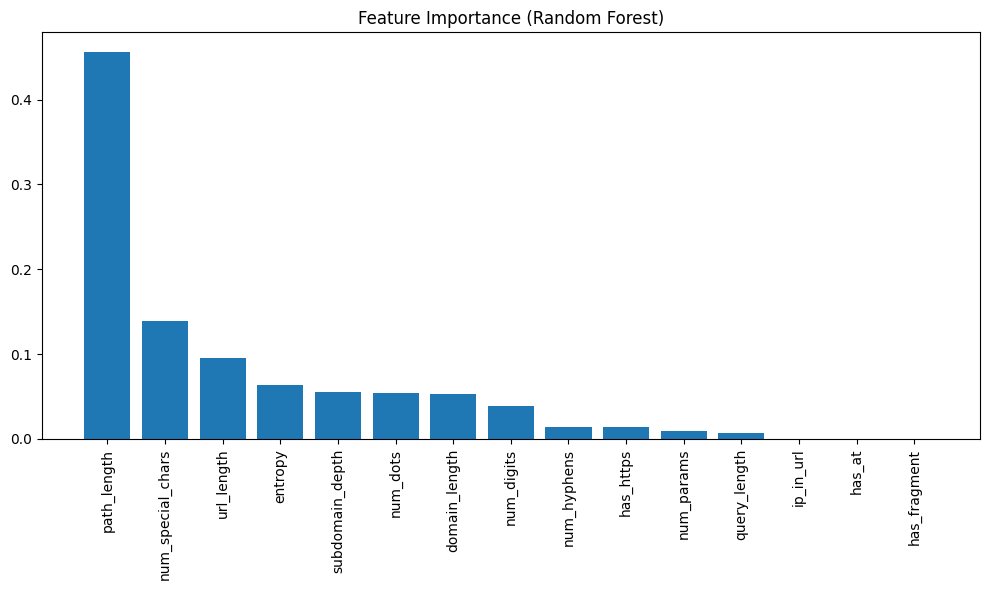

In [6]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


In [7]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

evaluate_model(gb, X_test, y_test)


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9000
           1       1.00      0.99      1.00      9331

    accuracy                           1.00     18331
   macro avg       1.00      1.00      1.00     18331
weighted avg       1.00      1.00      1.00     18331

ROC-AUC: 0.9982388692411199
Confusion Matrix:
 [[8995    5]
 [  72 9259]]


In [8]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline (scaling + SVM)
svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="linear",          # try 'linear' if slow
        C=1.0,
        probability=True,      # needed for ROC-AUC
        random_state=42
    ))
])

# Train
svc_pipeline.fit(X_train, y_train)

# Evaluate
evaluate_model(svc_pipeline, X_test, y_test)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9000
           1       1.00      0.99      0.99      9331

    accuracy                           0.99     18331
   macro avg       0.99      0.99      0.99     18331
weighted avg       0.99      0.99      0.99     18331

ROC-AUC: 0.9977363745698329
Confusion Matrix:
 [[9000    0]
 [ 107 9224]]
